In [244]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm, chisquare, expon, uniform
from scipy.stats import skew, kurtosis

# Parte 3
## Task 1

In [245]:
geometric_samples = stats.geom(p=0.3)
def transformacion_inversa_geometrica(p, n):
    u = np.random.rand(n)  
    samples = np.floor(np.log(1 - u) / np.log(1 - p)).astype(int)
    return samples
tamaño_muestra = 1000
muestra_aleatoria = transformacion_inversa_geometrica(0.3, tamaño_muestra)

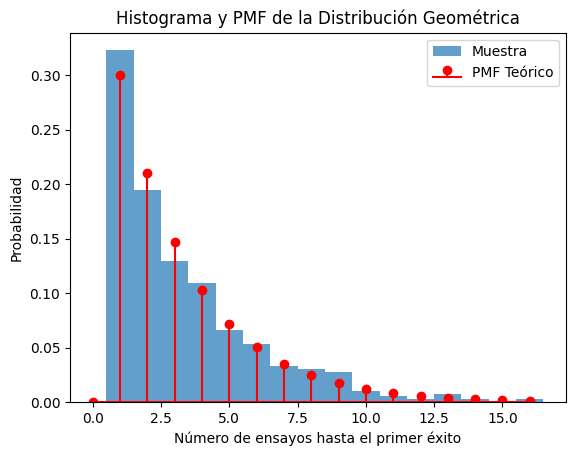

In [246]:
hist_data, bin_edges = np.histogram(muestra_aleatoria, bins=np.arange(1, np.max(muestra_aleatoria) + 2), density=True)

plt.bar(bin_edges[:-1], hist_data, width=1.0, alpha=0.7, label='Muestra')
x = np.arange(0, np.max(muestra_aleatoria) + 1)
theoretical_pmf = geometric_samples.pmf(x)
plt.stem(x, theoretical_pmf, linefmt='r-', markerfmt='ro', basefmt='r-', label='PMF Teórico')

plt.xlabel('Número de ensayos hasta el primer éxito')
plt.ylabel('Probabilidad')
plt.title('Histograma y PMF de la Distribución Geométrica')
plt.legend()
plt.show()

## Task 2

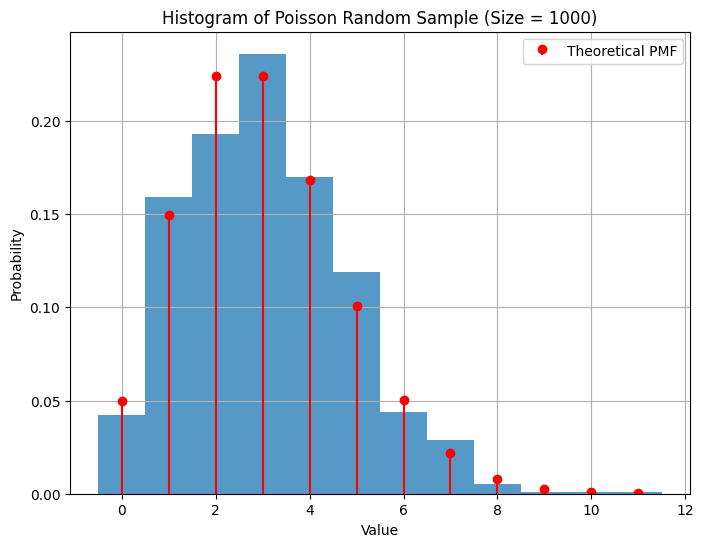

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, expon

# Función de para encontrar C
def calculate_constant(lambda_val):
    x = np.arange(0, 1000) 
    ratio = poisson.pmf(x, lambda_val) / (expon.pdf(x) + 1e-9)  
    return np.max(ratio)

# Exponencial
def generate_exponential_samples(size, scale):
    return np.random.exponential(scale=scale, size=size)

def rejection_sampling_poisson(size, lambda_val, constant_C):
    samples = []

    while len(samples) < size:
        x = np.random.poisson(lambda_val)
        normalized_proposal_PMF = expon.pdf(x) / constant_C  
        u = np.random.uniform(0, 1)

        if u <= poisson.pmf(x, lambda_val) / (normalized_proposal_PMF + 1e-9):  
            samples.append(x)

    return np.array(samples)

sample_size = 1000
lambda_val = 3
constant_C = calculate_constant(lambda_val)
random_sample = rejection_sampling_poisson(sample_size, lambda_val, constant_C)

plt.figure(figsize=(8, 6))
plt.hist(random_sample, bins=np.arange(min(random_sample) - 0.5, max(random_sample) + 1.5, 1), density=True, alpha=0.75)
plt.title(f'Histogram of Poisson Random Sample (Size = {sample_size})')
plt.xlabel('Value')
plt.ylabel('Probability')
plt.grid(True)

x = np.arange(0, max(random_sample) + 1)
pmf = poisson.pmf(x, lambda_val)
plt.stem(x, pmf, linefmt='r-', markerfmt='ro', basefmt='k ', label='Theoretical PMF')

plt.legend()
plt.show()


## Task 3

C:\Users\rober\AppData\Local\Temp\ipykernel_30040\3360152643.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(range(1, 11), [target_pmf(x) for x in range(1, 11)], 'ro-', label='Target PMF', color='red')


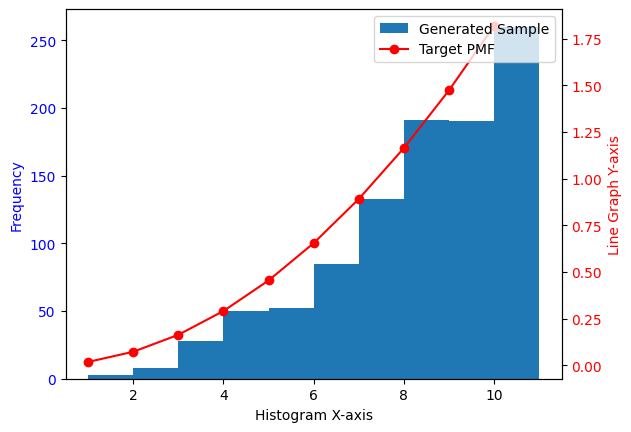

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def target_pmf(x):
    return (x ** 2) / 55

def proposal_pmf(x):
    return 1 / 10  

C = max(target_pmf(x) for x in range(1, 11)) / proposal_pmf(1)

def generate_sample(size):
    sample = []
    while len(sample) < size:
        x = np.random.randint(1, 11) 
        u = np.random.uniform(0, 1)  

        if u < target_pmf(x) / (C * proposal_pmf(x)):
            sample.append(x)

    return sample

sample_size = 1000
custom_sample = generate_sample(sample_size)

fig, ax1 = plt.subplots()
ax1.hist(custom_sample, bins=range(1, 12), label='Generated Sample')
ax1.set_xlabel('Histogram X-axis')
ax1.set_ylabel('Frequency', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(range(1, 11), [target_pmf(x) for x in range(1, 11)], 'ro-', label='Target PMF', color='red')
ax2.set_xlabel('Line Graph X-axis')
ax2.set_ylabel('Line Graph Y-axis', color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')


